In [47]:
import matplotlib.pyplot as plt 
import xarray as xr 
import cmocean as cmo 

fn = "/Users/siennawhite/research/scripts/demo_lisa/turbulence-model/demo_for_lisa.nc"
df = xr.open_dataset(fn)

print(df)
z = df.z 
time = df.t 
nt = len(time)
print(time.values)



<xarray.Dataset>
Dimensions:      (z: 80, t: 29)
Coordinates:
  * z            (z) float64 -9.938 -9.812 -9.688 ... -0.3125 -0.1875 -0.0625
  * t            (t) float64 190.0 390.0 590.0 ... 5.39e+03 5.59e+03 5.79e+03
Data variables:
    U            (z, t) float64 ...
    C            (z, t) float64 ...
    Q2           (z, t) float64 ...
    rho          (z, t) float64 ...
    nu_t         (z, t) float64 ...
    Kz           (z, t) float64 ...
    Kq           (z, t) float64 ...
    N_BV2        (z, t) float64 ...
    algae1       (z, t) float64 ...
    algae2       (z, t) float64 ...
    net_growth1  (z, t) float64 ...
    net_growth2  (z, t) float64 ...
Attributes:
    Px0:                   2e-06
    T_Px:                  12
    I_in:                  350
    Diurnal:               0
    Wind:                  nan
    pmax1:                 2.777777777777778e-05
    pmax2:                 2.222222222222222e-06
    ws1:                   -1.4e-05
    ws2:                   1.4e-05

<xarray.DataArray 'nu_t' (z: 80, t: 29)>
[2320 values with dtype=float64]
Coordinates:
  * z        (z) float64 -9.938 -9.812 -9.688 -9.562 ... -0.3125 -0.1875 -0.0625
  * t        (t) float64 190.0 390.0 590.0 790.0 ... 5.39e+03 5.59e+03 5.79e+03


(-9.9375, -0.0625)

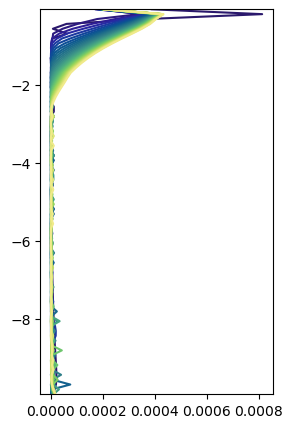

In [48]:
fig = plt.figure(figsize=(3,5))
ax = plt.gca()

print(df.nu_t)
for t in range(nt):
    color = cmo.cm.haline(t/nt)
    ax.plot(df.nu_t.isel(t=t), z, color=color, label="")
ax.set_ylim(z[0], z[-1])

Text(0.5, 1.0, 'Temperature (C)')

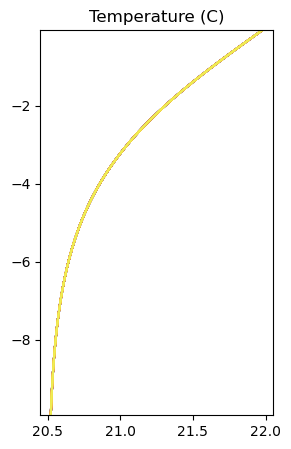

In [51]:
fig = plt.figure(figsize=(3,5))
ax = plt.gca()

for t in range(nt):
    color = cmo.cm.thermal(t/nt)
    ax.plot(df.C.isel(t=t), z, color=color, label="")
ax.set_ylim(z[0], z[-1])
ax.set_title("Temperature (C)")

In [50]:
# np.tanh(centered_z * stretch)*dtemp + self.base_temp